In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [2]:
df = pd.read_csv("15-iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

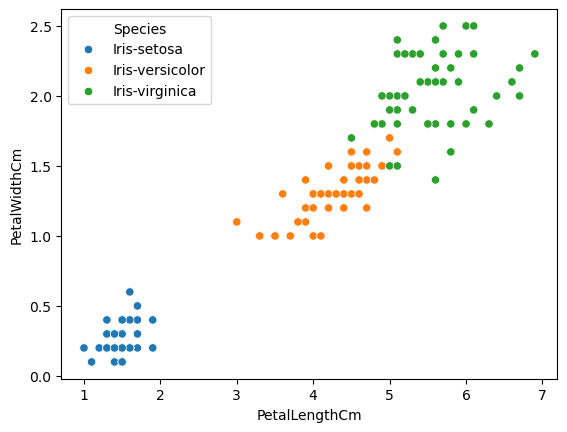

In [7]:
sns.scatterplot(data = df, x = 'PetalLengthCm', y = 'PetalWidthCm', hue = 'Species')
plt.show()

In [8]:
df = df.drop('Id', axis = 1)

In [9]:
X = df.drop('Species', axis = 1).values
y = df['Species'].values

In [10]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [12]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 42, stratify=y)

In [14]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.long)
y_test = torch.tensor(y_test, dtype = torch.long)

In [15]:
from torch import nn

In [16]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 4, out_features = 32)
        self.layer_2 = nn.Linear(in_features = 32, out_features = 32)
        self.layer_3 = nn.Linear(in_features = 32, out_features = 3)
        nn.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1))))

In [17]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features = 4, out_features = 32),
            nn.ReLU(),
            nn.Linear(in_features = 32, out_features = 32),
            nn.ReLU(),
            nn.Linear(in_features = 32, out_features = 3)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [18]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.001)

In [19]:
model(X_test)[:5]

tensor([[ 0.2653,  0.0249, -0.0888],
        [ 0.2212,  0.0762, -0.3385],
        [ 0.2268,  0.0421, -0.2210],
        [ 0.2283,  0.0455, -0.2332],
        [ 0.2596,  0.0296, -0.0992]], grad_fn=<SliceBackward0>)

In [20]:
y_logits = model(X_test)

y_pred_probs = torch.softmax(y_logits, dim = 1)

In [21]:
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 0.2653,  0.0249, -0.0888],
        [ 0.2212,  0.0762, -0.3385],
        [ 0.2268,  0.0421, -0.2210],
        [ 0.2283,  0.0455, -0.2332],
        [ 0.2596,  0.0296, -0.0992]], grad_fn=<SliceBackward0>)
tensor([[0.4019, 0.3160, 0.2821],
        [0.4104, 0.3550, 0.2345],
        [0.4048, 0.3365, 0.2587],
        [0.4060, 0.3381, 0.2559],
        [0.4011, 0.3187, 0.2802]], grad_fn=<SliceBackward0>)


In [22]:
torch.sum(y_pred_probs[0])

tensor(1.0000, grad_fn=<SumBackward0>)

In [23]:
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.4019, 0.3160, 0.2821], grad_fn=<SelectBackward0>)
tensor(0)


In [24]:
def calculate_accuracy(y_pred, y_test):
    correct = torch.eq(y_pred, y_test).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [25]:
epochs = 200

train_loses = []
test_loses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    # Train Step
    model.train()
    
    # 1. Forward Pass
    y_logits = model(X_train)
    y_preds = torch.softmax(y_logits, dim = 1).argmax(dim = 1)
    
    # 2. Calculate Loss and Accuracy
    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_preds, y_train)

    # 3. Optimizer Zero Grad
    optimizer.zero_grad()

    # 4.Backward Propagation
    loss.backward()

    # 5.Optimizer Step
    optimizer.step()


    
    train_accuracies.append(acc)
    train_loses.append(loss.item())

    # Test Step
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.softmax(test_logits, dim = 1).argmax(dim = 1)
        test_acc = calculate_accuracy(test_pred, y_test)

        test_loses.append(test_loss.item())
        test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}")
    

Epoch: 0 | Train Loss: 1.1513 | Train Acc: 33.33 | Test Loss: 1.1338 | Test Acc: 33.33
Epoch: 20 | Train Loss: 0.9671 | Train Acc: 84.17 | Test Loss: 0.9583 | Test Acc: 90.00
Epoch: 40 | Train Loss: 0.7930 | Train Acc: 86.67 | Test Loss: 0.7820 | Test Acc: 90.00
Epoch: 60 | Train Loss: 0.6075 | Train Acc: 96.67 | Test Loss: 0.5976 | Test Acc: 96.67
Epoch: 80 | Train Loss: 0.4630 | Train Acc: 96.67 | Test Loss: 0.4597 | Test Acc: 96.67
Epoch: 100 | Train Loss: 0.3613 | Train Acc: 97.50 | Test Loss: 0.3633 | Test Acc: 96.67
Epoch: 120 | Train Loss: 0.2827 | Train Acc: 97.50 | Test Loss: 0.2898 | Test Acc: 96.67
Epoch: 140 | Train Loss: 0.2217 | Train Acc: 97.50 | Test Loss: 0.2327 | Test Acc: 100.00
Epoch: 160 | Train Loss: 0.1739 | Train Acc: 97.50 | Test Loss: 0.1872 | Test Acc: 100.00
Epoch: 180 | Train Loss: 0.1401 | Train Acc: 97.50 | Test Loss: 0.1547 | Test Acc: 100.00


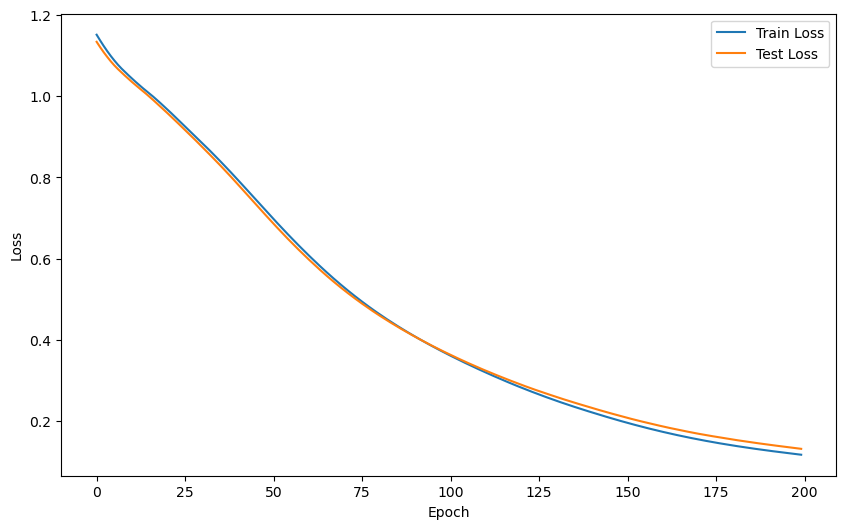

In [26]:
plt.figure(figsize=(10,6))
plt.plot(train_loses, label = 'Train Loss')
plt.plot(test_loses, label = 'Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

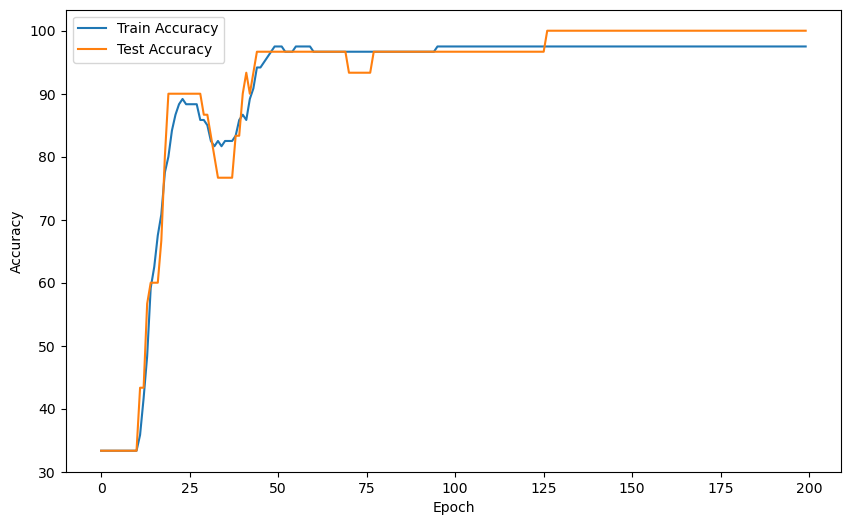

In [27]:
plt.figure(figsize=(10,6))
plt.plot(train_accuracies, label = 'Train Accuracy')
plt.plot(test_accuracies, label = 'Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [28]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [29]:
new_sample = torch.tensor(data = [[4.5, 3.0, 1.4, 0.2]])

In [30]:
model.eval()
with torch.inference_mode():
    test_logit = model(new_sample)
    test_pred = torch.softmax(test_logit, dim = 1).argmax(dim = 1).item()

print(test_pred)

0


In [31]:
test_result = le.inverse_transform([test_pred])[0]
print(test_result)

Iris-setosa


### torchmetrics kullanımı

In [32]:
#!pip install torchmetrics

In [33]:
from torchmetrics.classification import MulticlassAccuracy

In [35]:
model2 = IrisClassifier()
epochs = 200
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr = 0.001)
accuracy = MulticlassAccuracy(num_classes = 3)

for epoch in range(epochs):
    # Train STEP
    model2.train()

    # 1. Forward Pass
    y_logits = model2(X_train)
    y_preds = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

    # 2. Calculate Loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy(y_preds, y_train).item() * 100

    # 3. Optimizer Zero Grad
    optimizer.zero_grad()

    # 4. Loss Backward
    loss.backward()

    # 5. Optimizer Step
    optimizer.step()

    # Test STEP
    model2.eval()
    with torch.inference_mode():
        test_logits = model2(X_test)
        test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy(test_preds, y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.2831 | Acc: 11.67% | Test Loss: 1.2609 | Test Acc: 10.00%
Epoch 20 | Loss: 1.0571 | Acc: 33.33% | Test Loss: 1.0526 | Test Acc: 33.33%
Epoch 40 | Loss: 0.9184 | Acc: 66.67% | Test Loss: 0.9083 | Test Acc: 66.67%
Epoch 60 | Loss: 0.7400 | Acc: 69.17% | Test Loss: 0.7281 | Test Acc: 73.33%
Epoch 80 | Loss: 0.5694 | Acc: 78.33% | Test Loss: 0.5600 | Test Acc: 80.00%
Epoch 100 | Loss: 0.4635 | Acc: 88.33% | Test Loss: 0.4582 | Test Acc: 90.00%
Epoch 120 | Loss: 0.3920 | Acc: 95.00% | Test Loss: 0.3889 | Test Acc: 96.67%
Epoch 140 | Loss: 0.3320 | Acc: 97.50% | Test Loss: 0.3311 | Test Acc: 96.67%
Epoch 160 | Loss: 0.2789 | Acc: 97.50% | Test Loss: 0.2809 | Test Acc: 100.00%
Epoch 180 | Loss: 0.2309 | Acc: 97.50% | Test Loss: 0.2361 | Test Acc: 96.67%


In [37]:
from torchmetrics.classification import MulticlassConfusionMatrix
from torchmetrics.utilities.plot import plot_confusion_matrix

In [38]:
cm = MulticlassConfusionMatrix(3)
matrix = cm(test_preds, y_test)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

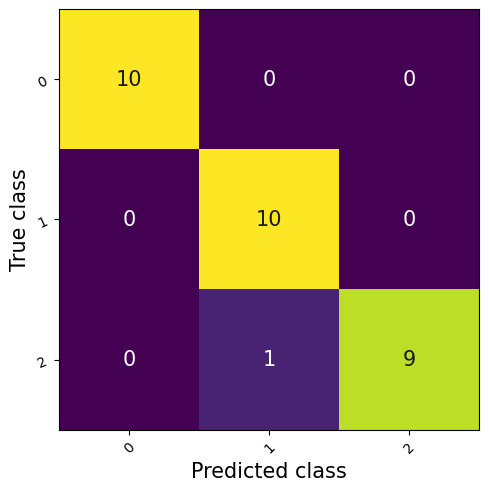

In [39]:
plot_confusion_matrix(matrix)

In [40]:
### Model Save and Load

In [41]:
from pathlib import Path

In [42]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

MODEL_NAME = "iris_classifiaction_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model2.state_dict(), f = MODEL_SAVE_PATH)

In [43]:
model2.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[-1.5115e-01,  1.5714e-01,  5.5176e-01, -8.0153e-02],
                      [-2.7062e-01, -4.9129e-01,  1.2654e-01, -1.9973e-01],
                      [-1.9378e-01,  4.3529e-03,  5.2889e-01,  2.8777e-01],
                      [-2.9044e-01, -3.5940e-01,  2.4392e-01,  2.5759e-01],
                      [ 6.0041e-01, -4.3607e-01,  3.2831e-01,  2.4963e-01],
                      [ 1.0917e-01,  3.6585e-01, -1.8629e-01, -4.4900e-01],
                      [ 1.7449e-01, -2.8587e-01, -2.7500e-01,  1.9460e-02],
                      [-4.9830e-01, -1.1145e-01,  2.7872e-01,  2.5269e-01],
                      [-4.2941e-01,  3.6817e-01,  8.1502e-02,  2.1196e-02],
                      [-1.1447e-01, -1.0024e-01, -4.5416e-01, -3.2334e-01],
                      [ 4.9311e-01,  4.6410e-01, -4.0288e-01, -5.9980e-01],
                      [-3.4372e-01,  1.6895e-01,  1.6469e-01, -2.6910e-01],
                      [-8.9142e-02, -2.6522e-04,  

In [44]:
loaded_model = IrisClassifier()

In [45]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_15168\228518556.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(MODEL_SAVE

<All keys matched successfully>

In [47]:
new_sample = torch.tensor(data = [[4.5, 3.0, 1.4, 0.2]])
loaded_model.eval()
with torch.inference_mode():
    test_logit = loaded_model(new_sample)
    test_pred = torch.softmax(test_logit, dim = 1).argmax(dim = 1).item()

test_result = le.inverse_transform([test_pred])[0]
print(test_result)

Iris-setosa
